### Setup

- Difffusers

In [1]:
# !git clone https://github.com/huggingface/diffusers.git
# %cd diffusers
# !pip install .
# %cd ..

- Peft

In [2]:
# !git clone https://github.com/huggingface/peft.git
# %cd peft
# !pip install .
# %cd ..

- Library

In [1]:
import torch, transformers, datasets, diffusers, peft
import random
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import os
import json
from datasets import Dataset, DatasetDict
from tqdm import tqdm
from PIL import Image
from IPython.display import display

import torch
import torch.nn.functional as F
from torchvision import transforms
from torchmetrics.image.fid import FrechetInceptionDistance

import transformers, datasets, diffusers
from transformers import CLIPTextModel, CLIPTokenizer
from huggingface_hub import login

from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler, StableDiffusionPipeline, StableDiffusionPipeline
from diffusers.optimization import get_scheduler
from diffusers.utils import convert_state_dict_to_diffusers
from diffusers.training_utils import cast_training_params

from peft import LoraConfig
from peft.utils import get_peft_model_state_dict

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device : ',device)   
print('package version : ',torch.__version__, transformers.__version__, datasets.__version__, diffusers.__version__, peft.__version__)

# BASIC CONFIG
CURRENT_TIME = datetime.now().strftime("%Y%m%d_%H%M%S")

# TRAIN CONFIG
MASTER_SEED = 42
PRE_TRAINED_MODEL_NAME="stablediffusionapi/deliberate-v2"
IMG_SIZE = 512
BATCH_SIZE = 4
NUM_WORKERS = 4
EPOCHS = 50
LEARNING_RATE = 1e-04
TRAIN_DATA_SIZE = 1800
TEST_DATA_SIZE = 200

# PATH
CONFIG_PATH = '../config.json'

TRAIN_IMAGE_FOLDER = '../Data/Total/Train_Image' # change path
TRAIN_LABEL_FOLDER = '../Data/Total/Train_Label_CLIP_Summarize' # change path
TRAIN_IMAGE_FILE = sorted([f for f in os.listdir(TRAIN_IMAGE_FOLDER) if f.endswith('.jpg')])
TRAIN_LABEL_FILE = sorted([f for f in os.listdir(TRAIN_LABEL_FOLDER) if f.endswith('.json')])

TEST_IMAGE_FOLDER = '../Data/Total/Test_Image_KFashion' # change path
TEST_LABEL_FOLDER = '../Data/Total/Test_Label_CLIP_Summarize' # change path
TEST_IMAGE_FILE = sorted([f for f in os.listdir(TEST_IMAGE_FOLDER) if f.endswith('.jpg')])
TEST_LABEL_FILE = sorted([f for f in os.listdir(TEST_LABEL_FOLDER) if f.endswith('.json')])

SAVE_MODEL_PATH = f"../Experiment/model/FIGMA_{CURRENT_TIME}"
SAVE_WEIGHTS_PATH = f"../Experiment/model_weights/FIGMA_weights_{CURRENT_TIME}"

# HUGGINGFACE
with open(CONFIG_PATH,'r') as f:
    config = json.load(f)
HUGGING_FACE_TOKEN = config.get("HUGGING_FACE_TOKEN")
login(HUGGING_FACE_TOKEN)

2025-02-26 13:03:25.271281: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-26 13:03:25.300469: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-26 13:03:25.795237: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


device :  cuda
package version :  2.4.1+cu124 4.46.2 3.0.1 0.33.0.dev0 0.7.0


### Load Model

In [2]:
noise_scheduler = DDPMScheduler.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="scheduler"
)
tokenizer = CLIPTokenizer.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="tokenizer"
)
text_encoder = CLIPTextModel.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="text_encoder"
)
vae = AutoencoderKL.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="vae"
)
unet = UNet2DConditionModel.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="unet"
)
# 모델에 입력되는 최대 토큰 길이
tokenizer.model_max_length

77

### Preprocess Data

In [3]:
# 주어진 데이터 샘플에서 text 컬럼을 토크나이징하여 토큰 ID tensor를 반환하는 함수.
def tokenize_captions(examples, caption_column='text', is_train=True):
    captions = []
    for caption in examples[caption_column]:
        # 캡션이 하나인 경우
        if isinstance(caption, str):
            captions.append(caption)
        # 캡션이 하나 이상인 경우 아무거나 하나 선택
        elif isinstance(caption, (list, np.ndarray)):
            # take a random caption if there are multiple
            captions.append(random.choice(caption) if is_train else caption[0])
        else:
            raise ValueError(
                f"Caption column `{caption_column}` should contain either strings or lists of strings."
            )
    inputs = tokenizer(
        captions, max_length=tokenizer.model_max_length, padding="max_length", truncation=True, return_tensors="pt"
    )

    return inputs.input_ids

# 이미지 데이터를 학습용으로 전처리하는 변환 파이프라인
train_transforms = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(IMG_SIZE) if True else transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip() if True else transforms.Lambda(lambda x: x),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]), # (0,1)->(-1,1)
    ]
)

# 이미지 데이터를 RGB로 변환 후 전처리하고, text 컬럼을 토크나이징하여 학습 데이터셋을 구성하는 함수.
def preprocess_train(examples, image_column='image'):
    images = [image.convert("RGB") for image in examples[image_column]]
    # 이미지 전처리
    examples["pixel_values"] = [train_transforms(image) for image in images]
    # 텍스트 전처리
    examples["input_ids"] = tokenize_captions(examples)
    return examples

# 배치 단위로 이미지와 토큰 ID를 스택하여 PyTorch 텐서 형태로 변환하는 함수.
def collate_fn(examples):
    # (C, H, W), ..., (C, H, W) -> stack -> (N, C, H, W): N으로 스택
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    # tensor.contiguous()와 동일
    pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()
    # {(77,), ..., (77,)}_N개 -> stack -> (N, 77)
    input_ids = torch.stack([example["input_ids"] for example in examples])

    return {"pixel_values": pixel_values, "input_ids": input_ids}


- Train Data

In [4]:
data = []
for image_file, label_file in zip(TRAIN_IMAGE_FILE, TRAIN_LABEL_FILE):
    image_path = os.path.join(TRAIN_IMAGE_FOLDER, image_file)
    label_path = os.path.join(TRAIN_LABEL_FOLDER, label_file)
    # 이미지 파일 열기
    with open(image_path, 'rb') as image:
        image_data = Image.open(image)
        image_data = image_data.convert('RGB') 
    # 라벨 파일 열기
    with open(label_path, 'r') as label:
        label_data = json.load(label)  
    # 이미지와 라벨 데이터 묶기
    data.append({
        'image':image_data,
        'text':label_data
    })
    
# Dataset으로 변환
dataset = Dataset.from_dict({
    'image': [item['image'] for item in data],
    'text': [item['text']['summary'] for item in data]
})

# Train DatasetDict 생성
train_dataset = DatasetDict({'train': dataset})

# Train Data Loader 생성
train_dataset = train_dataset.with_transform(preprocess_train)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset['train'],
    shuffle=True,
    collate_fn=collate_fn,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

print(train_dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 1800
    })
})


- Test Data

In [5]:
data = []
for image_file, label_file in zip(TEST_IMAGE_FILE, TEST_LABEL_FILE):
    image_path = os.path.join(TEST_IMAGE_FOLDER, image_file)
    label_path = os.path.join(TEST_LABEL_FOLDER, label_file)
    # 이미지 파일 열기
    with open(image_path, 'rb') as image:
        image_data = Image.open(image)
        image_data = image_data.convert('RGB')
    # 라벨 파일 열기
    with open(label_path, 'r') as label:
        label_data = json.load(label)
    # 이미지와 라벨 데이터 묶기
    data.append({
        'image':image_data,
        'text':label_data
    })
    
# Dataset으로 변환
dataset = Dataset.from_dict({
    'image': [item['image'] for item in data],
    'text': [item['text']['summary'] for item in data]
})

# Test DatasetDict 생성
test_dataset = DatasetDict({'test': dataset})

# Test Data Loader 생성
test_dataset = test_dataset.with_transform(preprocess_train)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset['test'],
    shuffle=False,
    collate_fn=collate_fn,
    batch_size=BATCH_SIZE,
    num_workers=0,
)
print(test_dataset)

DatasetDict({
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 200
    })
})


- Checking Data 

In [6]:
# # 데이터 로더 테스트
# test_dataloader_iter = iter(test_dataloader)
# mini_batch = next(test_dataloader_iter)

# # 이미지 데이터, 캡션 데이터
# print('Image Data : ', mini_batch['pixel_values'].shape)
# print('Caption Data : ', mini_batch['input_ids'].shape)

# # 트랜스포머 인코더의 마지막 히든층 츨력이므로 크기는 (batch size, time step, model dim)
# print('Text Encoder : ', text_encoder(mini_batch['input_ids'])[0].shape)

### Train Setting

In [7]:
# FP16을 AMP으로 적용하기 위한 세팅
weight_dtype = torch.float16 
# unet, vae와 텍스트 인코더는 미세조정에서 학습되지 않음
unet.requires_grad_(False)
vae.requires_grad_(False)
text_encoder.requires_grad_(False);

# LoRA Adapter 준비
LORA_RANK = 4
# Freeze the unet parameters before adding adapters
for param in unet.parameters():
    param.requires_grad_(False)
unet_lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_RANK,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)
# GPU로 이동
text_encoder.to(device);
vae.to(device);
unet.to(device);
unet.add_adapter(unet_lora_config)

# Cast the trainable parameters to float32
if weight_dtype == torch.float16:
    # only upcast trainable parameters (LoRA) into fp32
    cast_training_params(unet, dtype=torch.float32)

lora_layers = filter(lambda p: p.requires_grad, unet.parameters())

# Optimizer 설정
optimizer = torch.optim.AdamW(
        lora_layers,
        lr=LEARNING_RATE,
    )
# Scheduler 설정
lr_scheduler = get_scheduler(
        'linear',
        optimizer=optimizer,
        num_warmup_steps=500,
        num_training_steps=EPOCHS * len(train_dataloader)
    )

### Train Loop

In [8]:
use_amp = True
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
prediction_type = None  # 'epsilon' 또는 'v_prediction'
train_losses = []

for epoch in range(EPOCHS):
    unet.train()
    text_encoder.train()
    vae.train()
    
    for step, batch in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")):
        with torch.autocast(device_type=device, dtype=weight_dtype, enabled=use_amp):
            # latent encoding
            latents = vae.encode(batch["pixel_values"].to(device)).latent_dist.sample()
            latents = latents * vae.config.scaling_factor
            
            # 노이즈 추가 및 timestep 생성
            noise = torch.randn_like(latents)
            bsz = latents.shape[0]
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=latents.device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
            
            # 텍스트 임베딩 추출
            encoder_hidden_states = text_encoder(batch["input_ids"].to(device))[0]
            if prediction_type is not None:
                noise_scheduler.register_to_config(prediction_type=prediction_type)
            if noise_scheduler.config.prediction_type == "epsilon":
                target = noise
            elif noise_scheduler.config.prediction_type == "v_prediction":
                target = noise_scheduler.get_velocity(latents, noise, timesteps)
            else:
                raise ValueError(f"Unknown prediction type {noise_scheduler.config.prediction_type}")
            
            # UNet으로 노이즈 예측 후 loss 계산
            model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
            loss = F.mse_loss(model_pred.float(), target.float(), reduction="mean")
        
        train_losses.append(loss.item())
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()
        optimizer.zero_grad()
    
    avg_train_loss = sum(train_losses[-100:]) / 100
    print(f'Finished epoch {epoch+1}. Average training loss (last 100): {avg_train_loss:05f}')


/tmp/ipykernel_2885790/2005148523.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
Epoch 1/50: 100%|██████████| 450/450 [02:05<00:00,  3.58it/s]


Finished epoch 1. Average training loss (last 100): 0.108167


Epoch 2/50: 100%|██████████| 450/450 [02:05<00:00,  3.60it/s]


Finished epoch 2. Average training loss (last 100): 0.107322


Epoch 3/50: 100%|██████████| 450/450 [02:05<00:00,  3.60it/s]


...

Epoch 10/50: 100%|██████████| 450/450 [02:05<00:00,  3.60it/s]


Finished epoch 10. Average training loss (last 100): 0.113720


Epoch 11/50: 100%|██████████| 450/450 [02:04<00:00,  3.60it/s]


Finished epoch 11. Average training loss (last 100): 0.105802


Epoch 12/50:  38%|███▊      | 169/450 [00:46<01:18,  3.60it/s]

### Evaluate

In [ ]:
# 텍스트 조건으로부터 이미지를 생성하는 간단한 샘플링 함수
def generate_images_from_batch(batch, num_inference_steps=50):
    generated_images = []
    # 입력 텐서를 device로 이동 및 텍스트 인코딩
    input_ids = batch["input_ids"].to(device)
    encoder_hidden_states = text_encoder(input_ids)[0]
    batch_size = input_ids.shape[0]
    
    # 배치의 이미지 shape에서 height와 width 추출 (예: (B, C, H, W))
    _, _, H, W = batch["pixel_values"].shape
    # 일반적으로 VAE는 8배 downscale을 사용하므로
    latent_shape = (1, vae.config.latent_channels, H // 8, W // 8)
    
    for i in range(batch_size):
        # 개별 예제에 대한 텍스트 임베딩 추출
        single_embedding = encoder_hidden_states[i].unsqueeze(0)
        # 생성 시작: 정규분포로부터 latent 초기화
        latent = torch.randn(latent_shape, device=device)
        
        # Reverse diffusion sampling (간단화된 버전)
        for t in reversed(range(num_inference_steps)):
            timestep = torch.tensor([t], device=device).long()
            with torch.no_grad():
                latent_model_input = latent
                noise_pred = unet(latent_model_input, timestep, single_embedding).sample
                # noise_scheduler.step()은 하나의 denoising 단계를 수행하며, prev_sample 속성을 반환한다고 가정
                latent = noise_scheduler.step(noise_pred, timestep, latent).prev_sample
        
        # latent를 이미지로 디코딩 (scaling_factor로 나누어 조정)
        with torch.no_grad():
            image = vae.decode(latent / vae.config.scaling_factor).sample
            # [0,1] 범위로 clamp (디코딩된 이미지가 이 범위를 벗어날 경우)
            image = torch.clamp(image, 0, 1)
        generated_images.append(image)
    
    # 배치 차원으로 이미지들을 결합
    generated_images = torch.cat(generated_images, dim=0)
    return generated_images

In [ ]:
# FID metric 초기화
fid_metric = FrechetInceptionDistance(feature=64).to(device)
fid_metric.reset()
unet.eval()
text_encoder.eval()
vae.eval()

for step, batch in enumerate(tqdm(test_dataloader, desc="Evaluating on test set")):
    with torch.no_grad():
        # 텍스트 조건에 따른 이미지 생성
        generated_imgs = generate_images_from_batch(batch, num_inference_steps=50)
        # 생성된 이미지는 [0,1] 범위의 float이므로, [0,255] 범위의 uint8로 변환
        generated_imgs_uint8 = (generated_imgs * 255).round().to(torch.uint8)
        
        # 실제 이미지: 전처리 시 Normalize([0.5],[0.5])가 적용되어 [-1,1] 범위이므로, [0,1]로 복원 후 변환
        real_imgs = batch["pixel_values"].to(device)
        real_imgs_denorm = real_imgs * 0.5 + 0.5
        real_imgs_uint8 = (real_imgs_denorm * 255).round().to(torch.uint8)
        
        # FID metric 업데이트
        fid_metric.update(generated_imgs_uint8, real=False)
        fid_metric.update(real_imgs_uint8, real=True)

fid_score = fid_metric.compute()
print(f'Final test FID score: {fid_score:.5f}')

Evaluating on test set: 100%|██████████| 1/1 [00:04<00:00,  4.08s/it]

Final test FID score: 396.09775


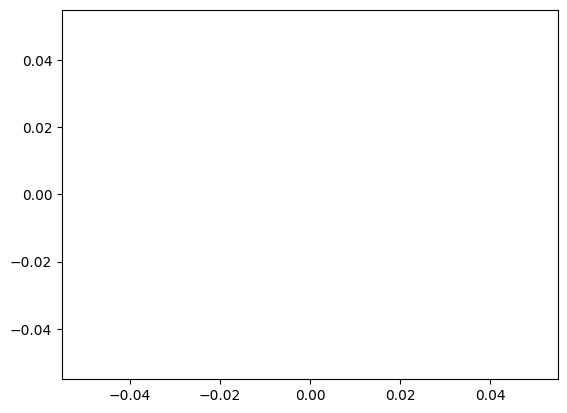

In [ ]:
losses_sr = pd.Series(train_losses)
loss_mv = losses_sr.rolling(window=300).mean()
plt.plot(loss_mv)

### Construct Pipeline

In [ ]:
pipeline = StableDiffusionPipeline.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    text_encoder=text_encoder,
    vae=vae,
    unet=unet,
)
pipeline.to(device);

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/home/gayeon38/anaconda3/envs/vlm-env/lib/python3.8/site-packages/transformers/models/clip/feature_extraction_clip.py:28: FutureWarning: The class CLIPFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use CLIPImageProcessor instead.
  warnings.warn(


### Save Fine-Tuned Model

In [ ]:
# save model 
pipeline.save_pretrained(SAVE_MODEL_PATH)
# save model weights
unet_lora_state_dict = convert_state_dict_to_diffusers(get_peft_model_state_dict(unet))
StableDiffusionPipeline.save_lora_weights(
    save_directory=SAVE_WEIGHTS_PATH,
    unet_lora_layers=unet_lora_state_dict,
    safe_serialization=True,
)

### Load Fine-Tuning Model
- LoRA Fine-Tuning 시 베이스 모델(Stable diffusion의 UNet)에 추가된 LoRA파라미터만 업데이트되고, 베이스 모델의 원본 가중치 저장X
- 저장된 pipeline에는 UNet의 기본 가중치X, LoRA델타만 포함됨
- 베이스 모델을 별도로 로드한 후 Fine-Tuning한 LoRA 가중치 적용

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

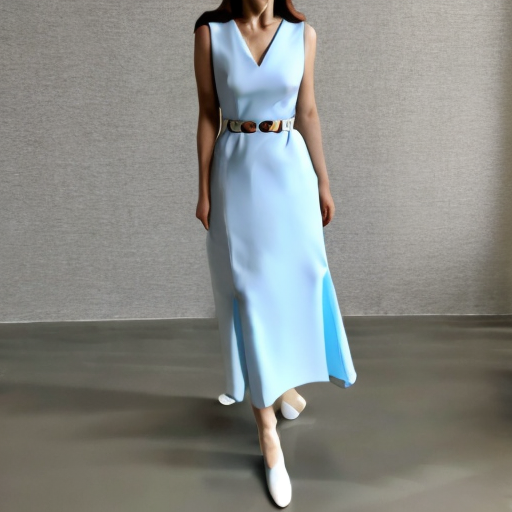

In [ ]:
# 저장된 모델 불러오기
pipe = StableDiffusionPipeline.from_pretrained(PRE_TRAINED_MODEL_NAME, torch_dtype=torch.float16)
pipe.to("cuda")
pipe.load_lora_weights(SAVE_WEIGHTS_PATH, safe_serialization=True)

# prompt에 기반한 이미지 생성
prompt = "a sky blue dress with a white belt and a white collar"
generated_image = pipe(prompt).images[0]
generated_image

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

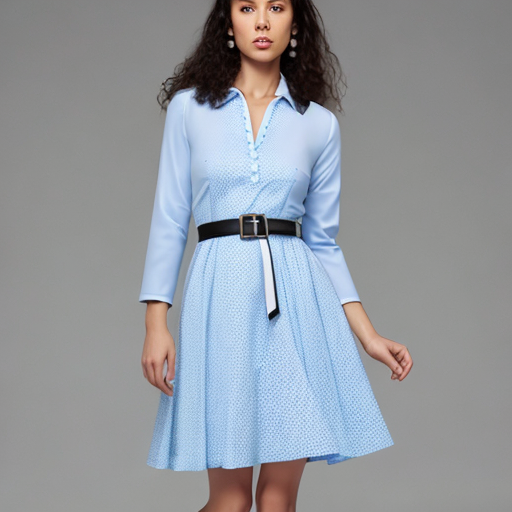

In [ ]:
# 원본 모델
pipe = StableDiffusionPipeline.from_pretrained(PRE_TRAINED_MODEL_NAME, torch_dtype=torch.float16)
pipe.to("cuda")
# prompt에 기반한 이미지 생성
prompt = "a sky blue dress with a white belt and a white collar"
generated_image = pipe(prompt).images[0]
generated_image